In [7]:
import numpy as np
import pandas as pd

In [8]:
import matplotlib.pyplot as plt

In [1]:
data=pd.read_csv("tourist_spots.csv")

NameError: name 'pd' is not defined

In [2]:
data.head

NameError: name 'data' is not defined

In [3]:

from sklearn.cluster import  DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [4]:
df_valid_locations = data.dropna(subset=['longitude', 'latitude'])
locations = df_valid_locations[['longitude', 'latitude']]

NameError: name 'data' is not defined

In [13]:
# Standardize the data
scaler = StandardScaler()
locations_scaled = scaler.fit_transform(locations)

In [14]:
# Initialize clustering algorithms
dbscan = DBSCAN(eps=0.5, min_samples=5)


In [15]:
# Fit the models
clusters_dbscan = dbscan.fit_predict(locations_scaled)

In [16]:

silhouette_dbscan = silhouette_score(locations_scaled, clusters_dbscan) if len(set(clusters_dbscan)) > 1 else -1

Silhouette Score for DBSCAN: 0.47847311347564103


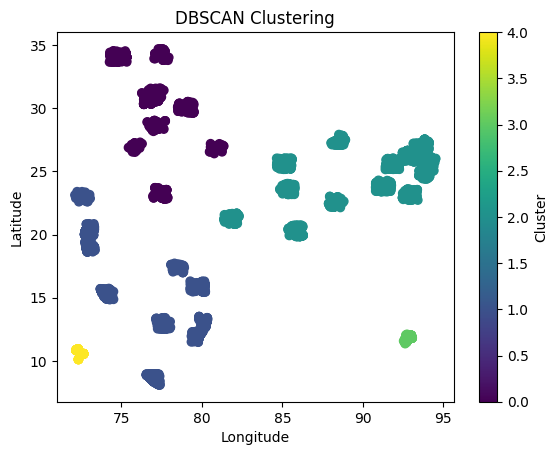

In [ ]:

print(f'Silhouette Score for DBSCAN: {silhouette_dbscan}')

def plot_clusters(locations, labels, title):
    plt.scatter(locations['longitude'], locations['latitude'], c=labels, cmap='viridis', marker='o')
    plt.colorbar(label='Cluster')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(title)
    plt.show()

plot_clusters(df_valid_locations, clusters_dbscan, 'DBSCAN Clustering')



In [5]:
from geopy.distance import geodesic

def get_nearby_locations(user_location, cluster_data, radius):
    nearby_locations = []
    for index, row in cluster_data.iterrows():
        distance = geodesic(user_location, (row['latitude'], row['longitude'])).km
        if distance <= radius:
            nearby_locations.append((row['latitude'], row['longitude'], distance))
    return pd.DataFrame(nearby_locations, columns=['Latitude', 'Longitude', 'Distance'])


In [6]:

# Example usage
user_location = (12.134111,78.156766)  # User's current latitude and longitude
radius =300 # Flexible radius in kilometers
nearby_spots = get_nearby_locations(user_location, df_valid_locations, radius)
print(nearby_spots)

NameError: name 'df_valid_locations' is not defined

In [7]:
def recommend_tourist_spots(user_location, cluster_labels, locations_data, radius):
    recommended = []
    for cluster_label in set(cluster_labels):
        cluster_points = locations_data[cluster_labels == cluster_label]
        cluster_df = pd.DataFrame(cluster_points, columns=['longitude', 'latitude'])
        nearby = get_nearby_locations(user_location, cluster_df, radius)
        if not nearby.empty:
            recommended.extend(nearby.values)
    return pd.DataFrame(recommended, columns=['Latitude', 'Longitude', 'Distance'])

recommendations = recommend_tourist_spots(user_location, clusters_dbscan, locations_scaled, radius)
print(recommendations)

NameError: name 'clusters_dbscan' is not defined

In [8]:
import folium
import requests

def get_route_osrm(start, end):
    """
    Fetches the route from OSRM for road-following paths.
    :param start: Tuple of (latitude, longitude) for the start point.
    :param end: Tuple of (latitude, longitude) for the end point.
    :return: List of (latitude, longitude) tuples representing the route.
    """
    url = f"http://router.project-osrm.org/route/v1/driving/{start[1]},{start[0]};{end[1]},{end[0]}"
    params = {"overview": "full", "geometries": "geojson"}
    response = requests.get(url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        coordinates = data['routes'][0]['geometry']['coordinates']
        # Convert from (longitude, latitude) to (latitude, longitude)
        return [(lat, lon) for lon, lat in coordinates]
    else:
        print(f"Error fetching route from OSRM: {response.status_code}")
        return []

def plot_on_map(user_location, recommended_spots, original_data):
    """
    Plots the user location, recommended tourist spots, and road-following paths.
    :param user_location: Tuple of user's latitude and longitude.
    :param recommended_spots: DataFrame of recommended spots with Latitude, Longitude, and Distance.
    :param original_data: DataFrame of all original location data.
    :return: Folium map with routes and markers.
    """
    # Create a map centered at the user's location
    tourist_map = folium.Map(location=user_location, zoom_start=12)

    # Add a marker for the user's location
    folium.Marker(
        location=user_location, 
        popup='Your Location', 
        icon=folium.Icon(color='blue')
    ).add_to(tourist_map)
    
    # Add paths and markers for each recommended spot
    for _, row in recommended_spots.iterrows():
        # Match the latitude and longitude to get the title from the original dataset
        match = original_data[
            (original_data['latitude'] == row['Latitude']) & 
            (original_data['longitude'] == row['Longitude'])
        ]
        
        if not match.empty:
            title = match.iloc[0]['Name']  # Get the title from the original dataset
            popup_content = f"Title: {title}<br>Distance: {row['Distance']:.2f} km"
            
            # Add a marker for the location
            folium.Marker(
                location=(row['Latitude'], row['Longitude']),
                popup=popup_content,
                icon=folium.Icon(color='green')
            ).add_to(tourist_map)
            
            # Fetch the route from OSRM starting from the user's location
            route = get_route_osrm(user_location, (row['Latitude'], row['Longitude']))
            
            # Draw the route if available
            if route:
                folium.PolyLine(
                    locations=route,
                    color='blue',  # Path color
                    weight=2.5,
                    opacity=1
                ).add_to(tourist_map)
            else:
                print(f"No route found for destination: {(row['Latitude'], row['Longitude'])}")

    return tourist_map

# Example usage
map_display = plot_on_map(user_location, nearby_spots, df_valid_locations)
map_display.save('tourist_recom_with_user_start.html')


NameError: name 'nearby_spots' is not defined